In [1]:
import sys
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

import threading
from concurrent.futures import ThreadPoolExecutor

import magcal
from thread_func import thread_func

### SC-TLI
L1-L2 penalty in the space domain and structural coupling in the temporal domain

$$
P(\boldsymbol{\beta}) = 
\lambda_s \left( \alpha \left\| \boldsymbol{\beta} \right\|_1 + \frac{1 - \alpha}{2} \| \boldsymbol{\beta} \|_2^2 \right)
+
\lambda_t \sum_{\mathcal{G}_j} \left\| \left( \boldsymbol{D} \boldsymbol{\beta} \right)_{\mathcal{G}_j} \right\|_2
$$

In [2]:
from SCTLI import ADMMGroupLasso

In [3]:
# data misfit
def misfit(f, K, beta):
    return 0.5 * np.linalg.norm(f - K.dot(beta))**2

# penalty
def pen1(beta, alpha):
    return alpha * np.linalg.norm(beta, ord=1) + (1 - alpha) * 0.5 * np.linalg.norm(beta)**2
    
def pen2(Dbeta, num_of_cells, times):
    pen2 = 0
    for k in range(num_of_cells):
        temp = 0
        for j in range(times-1):
            temp += Dbeta[k + j*num_of_cells]**2
        pen2 += np.sqrt(temp)
    return pen2

In [4]:
def calcCurvature2(x,y):
    
    dif_x = np.gradient(x)
    dif_y = np.gradient(y)
    dif2_x = np.gradient(dif_x)
    dif2_y = np.gradient(dif_y)
    
    curvature = np.abs(dif2_x * dif_y - dif_x * dif2_y) / (dif_x **2 + dif_y **2)**1.5
    return curvature

### 空間領域

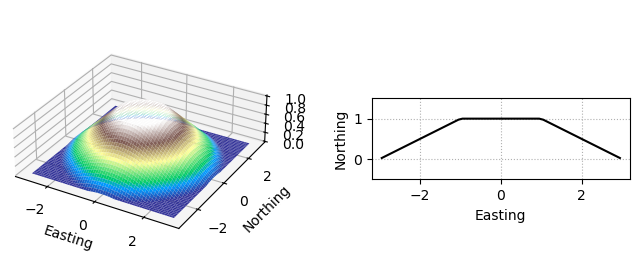

In [5]:
### 地下グリッドの作成: xgrd, ygrd, zgrd ###
# incx, incy, incz : x, y, z方向のグリッド間隔
incx = 0.1
incy = 0.1
incz = 0.1

x = np.arange(-3.0 + 0.5*incx, 3.0, incx)
y = np.arange(-3.0 + 0.5*incy, 3.0, incy)
nx = len(x)
ny = len(y)
X, Y = np.meshgrid(x, y)

# 山型の地形
T = np.zeros(X.shape)
for iy in range(len(y)):
    for ix in range(len(x)):
        r = np.sqrt(X[iy, ix]**2 + Y[iy, ix]**2)
        if r <= 1:
            T[iy, ix] = 1.
        elif (1 <= r) and (r <= 3):
            T[iy, ix] = - 0.5*r + 1.5

### 地下グリッドの作成: xgrd, ygrd, zgrd ###
# 地下の層数 = 30  # 60×60×30
nz = 30
[yy2, zz2, xx2] = np.meshgrid(y, np.zeros(nz), x)

for k in range(nz):
    for i in range(nx):
        for j in range(ny):
            zz2[k, j, i] = T.reshape(-1)[i + nx*j] - incz / 2. - incz*k
            
xgrd = xx2.reshape(-1)
ygrd = yy2.reshape(-1)
zgrd = zz2.reshape(-1)

# 図示用
xfig, yfig, zfig = [], [], []

for i in range(len(xgrd)):
    j = i // (nx*ny)
    
    # 各グリッドの8頂点の座標を格納
    xfig.append([xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, 
                 xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx])
    yfig.append([ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy, 
                 ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy])
    zfig.append([zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, 
                 zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz])

# array化
xfig = np.array(xfig)
yfig = np.array(yfig)
zfig = np.array(zfig)

#dim: ブロックのサイズ
dim = [[incx / 2., incx / 2.], [incy / 2., incy / 2.], [incz / 2., incz / 2.]]

# 東京付近
# 偏角(度)
dec = -7.
# 伏角(度)
inc = 50.

# 図示
fig = plt.figure(figsize = (8, 4))
plt.subplots_adjust(wspace=0.4, hspace=0.)

ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X, Y, T, rstride=1, cstride=1, cmap = plt.cm.terrain)
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_box_aspect((1,1,0.3))

ax = fig.add_subplot(122)
ys = 29
ax.plot(X[ys, :], T[ys,:], color = "black")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_aspect("equal")
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-0.5, 1.5)
ax.grid(linestyle = "dotted")

### 空中磁気探査（正規グリッド）

CPU times: total: 12.2 s
Wall time: 12.3 s


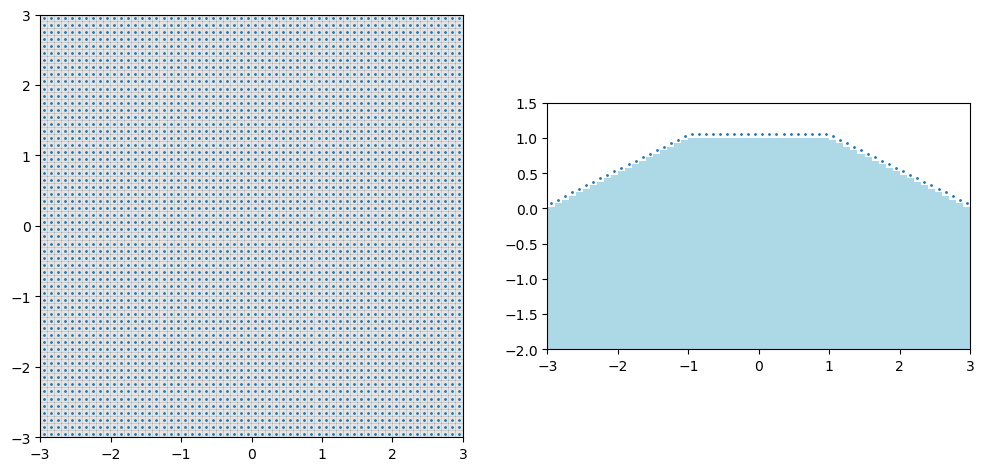

In [6]:
%%time
### 合成データの作成 ###
# 座標： x:東向きを正, y:北向きを正, z:鉛直上向きを正

### 観測点の作成: yobs, zobs ###
[xobs1, yobs1] = np.meshgrid(np.arange(-3.0 + 0.5*incx, 3.0, incx), np.arange(-3.0 + 0.5*incy, 3.0, incy))
xobs1 = xobs1.reshape(-1)
yobs1 = yobs1.reshape(-1)
zobs1 = np.zeros(len(xobs1))

for i in range(len(xobs1)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs1[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs1[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs1[i] = T.reshape(-1)[j] + 0.05 # 地表から 50 m

# 図示
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs1, yobs1, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs1[(0<yobs1)&(yobs1<incy)], zobs1[(0<yobs1)&(yobs1<incy)], s = 1)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### Kernel matrix

In [7]:
%%time
# threadingを用いた並列計算で核行列を求める
# 単位ベクトル作成
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# スレッドの数（並列計算を動かす数）
n = 12

# 全グリッドに関する計算範囲 i = [0, nz] を n 個に分割
p = np.linspace(0, nz - 1, n).astype(int)
p[-1] += 1
print(p)

# ThreadPool に各threadの返り値を格納させる
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs1, yobs1, zobs1, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# 計算結果を取り出し、積み上げて最終的な核行列にする
K1 = []
for res in results:
    Ki = res.result()
    if len(K1) == 0:
        K1 = Ki.copy()
    else:
        K1 = np.hstack((K1, Ki))

[ 0  2  5  7 10 13 15 18 21 23 26 30]
Processed cell index: 0
Processed cell index: 18000
Processed cell index: 36000
Processed cell index: 54000
Processed cell index: 65000
Processed cell index: 47000
Processed cell index: 83000
Processed cell index: 94000
Processed cell index: 76000
Processed cell index: 8000
Processed cell index: 26000
Processed cell index: 55000
Processed cell index: 19000
Processed cell index: 1000
Processed cell index: 37000
Processed cell index: 66000
Processed cell index: 48000
Processed cell index: 84000
Processed cell index: 77000
Processed cell index: 95000
Processed cell index: 9000
Processed cell index: 27000
Processed cell index: 20000
Processed cell index: 56000
Processed cell index: 2000
Processed cell index: 38000
Processed cell index: 67000
Processed cell index: 49000
Processed cell index: 85000
Processed cell index: 78000
Processed cell index: 96000
Processed cell index: 10000
Processed cell index: 28000
Processed cell index: 57000
Processed cell ind

In [8]:
# Depth weighting
w1 = np.linalg.norm(K1, axis=0)
X1 = K1 / w1

### Input models

In [9]:
### 磁化構造  ###

# 回転楕円状消磁源  
zcenter = -0.2
a_rad = 0.5 # 半径
b_rad = 0.5
c_rad = 0.5

# ------------------------------------------------------------ #

# Time1
beta1 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta1[k] = -4

# Time2
beta2 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta2[k] = -2

# Time3
beta3 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta3[k] = 1

# Time4
beta4 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta4[k] = 5

# ------------------------------------------------------------ #

# 磁気異常の計算
f1_row = K1.dot(beta1)
f2_row = K1.dot(beta2)
f3_row = K1.dot(beta3)
f4_row = K1.dot(beta4)

# ガウシアンノイズを加える 
np.random.seed(42)
noise1 = np.random.normal(loc=0, scale=5.0, size=len(f1_row)) # 5nT
noise2 = np.random.normal(loc=0, scale=5.0, size=len(f2_row)) # 5nT
noise3 = np.random.normal(loc=0, scale=5.0, size=len(f3_row)) # 5nT
noise4 = np.random.normal(loc=0, scale=5.0, size=len(f4_row)) # 5nT
fobs1 = f1_row + noise1
fobs2 = f2_row + noise2
fobs3 = f3_row + noise3
fobs4 = f4_row + noise4

bb1 = beta1.reshape(nz, ny, nx)
bb2 = beta2.reshape(nz, ny, nx)
bb3 = beta3.reshape(nz, ny, nx)
bb4 = beta4.reshape(nz, ny, nx)


<timed exec>:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
<timed exec>:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


CPU times: total: 5.27 s
Wall time: 5.3 s


<timed exec>:286: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
<timed exec>:316: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
<timed exec>:346: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
<timed exec>:376: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


Text(0.5, 1.0, 'Magnetic anomaly (nT)')

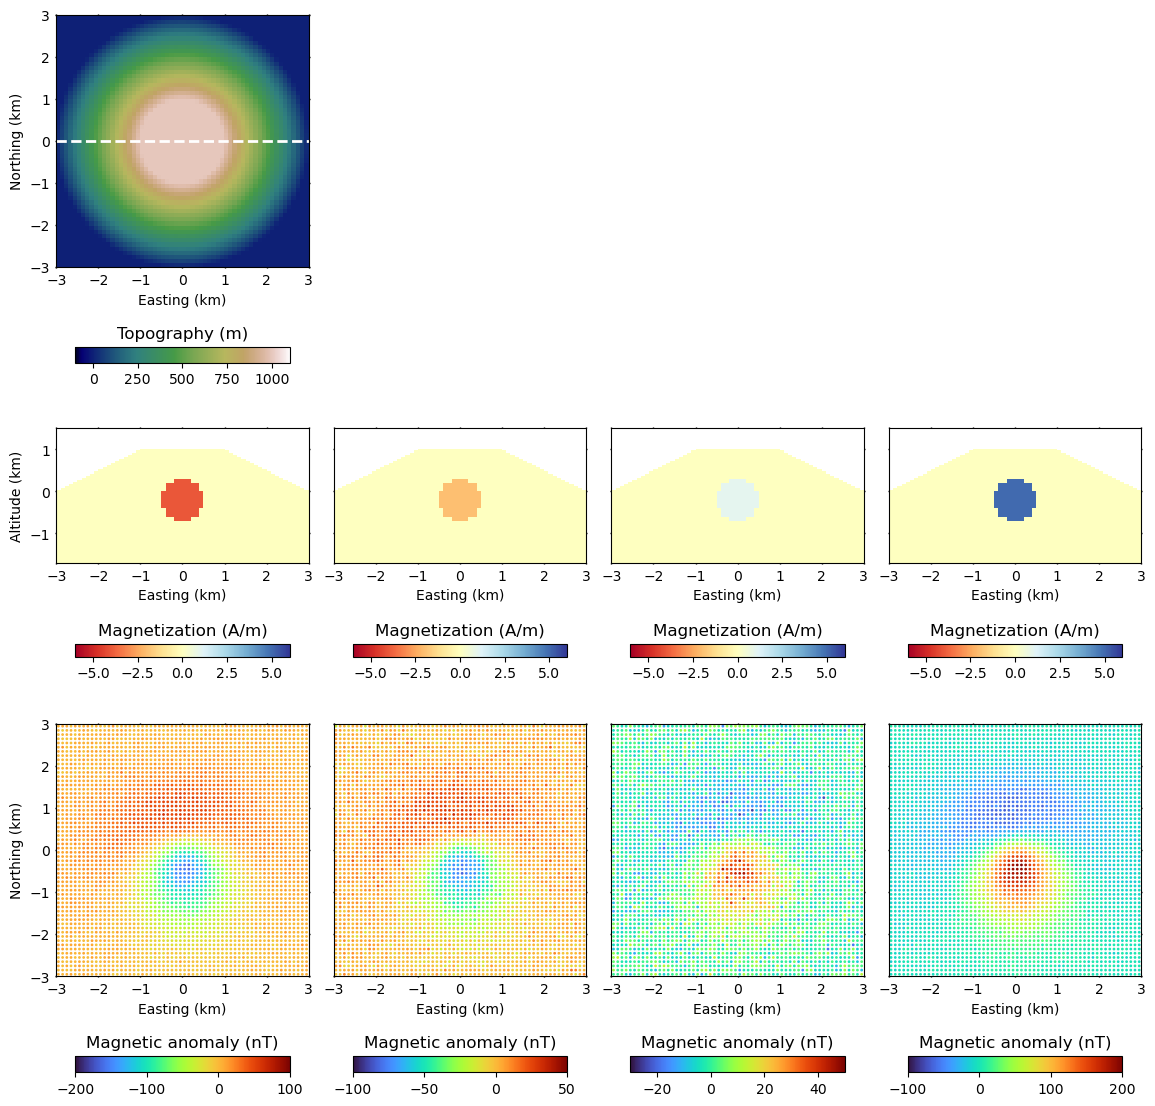

In [10]:
%%time
# カラーマップ
cmap = cm.get_cmap("gist_earth")
norm = Normalize(vmin = -100, vmax = 1100)

# 図示
fig = plt.figure(figsize = (14, 12.5))
plt.subplots_adjust(wspace=0.1, hspace=-0.3)

#--- Topography ---#

ax = fig.add_subplot(541)
p = ax.pcolor(X, Y, T*1e3, cmap = cmap)
p.set_clim(-100, 1100)

ax.plot([-3.0, 3.0], [0.0, 0.0], linestyle='--', color='white', linewidth=2)

ax.set_aspect("equal")
ax.set_xlim(-3, )
ax.set_ylim(-3, )
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Northing (km)")
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Topography (m)", fontsize = 12)


#--- Input model ---#

# カラーマップ
cmap = cm.get_cmap("RdYlBu")
norm = Normalize(vmin = -6, vmax = 6)

# T = T1
ax = fig.add_subplot(5,4,9)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta1[i]
        color = cmap(norm(beta_val))

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T2
ax = fig.add_subplot(5,4,10)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta2[i]
        color = cmap(norm(beta_val))

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_2$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T3
ax = fig.add_subplot(5,4,11)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta3[i]
        color = cmap(norm(beta_val))

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_3$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T4
ax = fig.add_subplot(5,4,12)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta4[i]
        color = cmap(norm(beta_val))

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_4$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

### data ###

# T = T_1
ax = fig.add_subplot(5,4,17)
p = ax.scatter(xobs1, yobs1, c = fobs1, cmap = "turbo", s = 1)
p.set_clim(-200, 100)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Northing (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# # その都度造り直す
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -200, vmax = 100)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_2
ax = fig.add_subplot(5,4,18)
p = ax.scatter(xobs1, yobs1, c = fobs2, cmap = "turbo", s = 1)
p.set_clim(-100, 50)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# # その都度造り直す
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -100, vmax = 50)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_3
ax = fig.add_subplot(5,4,19)
p = ax.scatter(xobs1, yobs1, c = fobs3, cmap = "turbo", s = 1)
p.set_clim(-30, 50)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# # その都度造り直す
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -30, vmax = 50)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_4
ax = fig.add_subplot(5,4,20)
p = ax.scatter(xobs1, yobs1, c = fobs4, cmap = "turbo", s = 1)
p.set_clim(-100, 200)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# # その都度造り直す
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -100, vmax = 200)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

### Joint Inversion

In [11]:
# Z
Z = np.r_[np.c_[X1, np.zeros(X1.shape), np.zeros(X1.shape), np.zeros(X1.shape)], 
          np.c_[np.zeros(X1.shape), X1, np.zeros(X1.shape), np.zeros(X1.shape)], 
          np.c_[np.zeros(X1.shape), np.zeros(X1.shape), X1, np.zeros(X1.shape)], 
          np.c_[np.zeros(X1.shape), np.zeros(X1.shape), np.zeros(X1.shape), X1]]

# f
fobs = np.r_[fobs1, fobs2, fobs3, fobs4]

# D
zeros = sp.sparse.diags(np.zeros(len(xgrd)))
D = sp.sparse.vstack([ sp.sparse.hstack([sp.sparse.diags(1 / w1), -sp.sparse.diags(1 / w1), zeros, zeros]), 
                       sp.sparse.hstack([zeros, sp.sparse.diags(1 / w1), -sp.sparse.diags(1 / w1), zeros]),
                       sp.sparse.hstack([zeros, zeros, sp.sparse.diags(1 / w1), -sp.sparse.diags(1 / w1)]),
                     ])

print(Z.shape, fobs.shape, D.shape)

(14400, 432000) (14400,) (324000, 432000)


In [ ]:
%%time
# parameter
eta = 1.0
rho = 1.0

# inverse matrix
inv1 = sp.sparse.linalg.inv(rho * sp.sparse.eye(Z.shape[1]) + eta * D.T * D)
inv2 = np.linalg.inv(np.eye(Z.shape[0]) + Z.dot(inv1 * Z.T))

C:\Users\ri710\anaconda3\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
C:\Users\ri710\anaconda3\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


### Step1

In [ ]:
# hyper-parameters
lams_s = np.power(10., np.arange(0.0, 2.6, 0.25))
print("lams_s = {}".format(lams_s))

lam_t = 10.0 # こちらは固定

In [ ]:
alpha = 0.9
rho = 1.0
eta = 1.0

In [ ]:
%%time
params_all = []
betas1_all = []
betas2_all = []
betas3_all = []
betas4_all = []

for lis in range(len(lams_s)):

    params_all.append([lams_s[lis], lam_t])
    print("lm1 = {}, lm2 = {}".format(lams_s[lis], lam_t))

    model = ADMMGroupLasso(lambda_s = lams_s[lis], lambda_t = lam_t, alpha = alpha, rho = rho, eta = eta, tol = 1.e-3)
    model.fit(fobs, Z, D, inv1, inv2, times = 4, num_of_cells = nx*ny*nz)
    
    beta_sim1 = model.beta_[0*nx*ny*nz:1*nx*ny*nz] / w1
    beta_sim2 = model.beta_[1*nx*ny*nz:2*nx*ny*nz] / w1
    beta_sim3 = model.beta_[2*nx*ny*nz:3*nx*ny*nz] / w1
    beta_sim4 = model.beta_[3*nx*ny*nz:4*nx*ny*nz] / w1

    betas1_all.append(beta_sim1)
    betas2_all.append(beta_sim2)
    betas3_all.append(beta_sim3)
    betas4_all.append(beta_sim4)

# ndarry
params_all = np.array(params_all)
betas1_all = np.array(betas1_all)
betas2_all = np.array(betas2_all)
betas3_all = np.array(betas3_all)
betas4_all = np.array(betas4_all)

In [ ]:
import pickle
with open('Params_new_4d_case_1_1-1.pickle', 'wb') as f:
    pickle.dump(params_all, f)
with open('Betas1_new_4d_case_1_1-1.pickle', 'wb') as f:
    pickle.dump(betas1_all, f)
with open('Betas2_new_4d_case_1_1-1.pickle', 'wb') as f:
    pickle.dump(betas2_all, f)
with open('Betas3_new_4d_case_1_1-1.pickle', 'wb') as f:
    pickle.dump(betas3_all, f)
with open('Betas4_new_4d_case_1_1-1.pickle', 'wb') as f:
    pickle.dump(betas4_all, f)

In [ ]:
# L-curve
rss2_1 = []
nrm2_1 = []

for lis in range(len(lams_s)):
    
    betas_temp = np.r_[betas1_all[lis]*w1, betas2_all[lis]*w1, betas3_all[lis]*w1, betas4_all[lis]*w1]
    rss_temp = misfit(fobs, Z, betas_temp)
    pen_temp = pen1(betas_temp, alpha = 0.9)
    
    rss2_1.append(rss_temp)
    nrm2_1.append(pen_temp)

In [ ]:
# curvature
fig = plt.figure(figsize = (10, 4))
fig.subplots_adjust(wspace=0.4)

ax = fig.add_subplot(121)
ax.semilogx(lams_s, calcCurvature2(np.log(rss2_1), np.log(nrm2_1)), "o", ms=6, color='#000000',markerfacecolor='#ffffff', linewidth = 1)

num_opt_1 = np.argmax(calcCurvature2(np.log(rss2_1), np.log(nrm2_1)))

ax.semilogx(lams_s[num_opt_1], calcCurvature2(np.log(rss2_1), np.log(nrm2_1))[num_opt_1], '^', ms=10, color = "black")
ax.set_xlabel(r'${\rm \lambda_s}$', fontsize = 12)
ax.set_ylabel(r'${\rm Curvature}$', fontsize = 12)

ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

#ax.set_xticks([0, 1e5, 2e5, 3e5])
#ax.ticklabel_format(style="sci",  axis="x",scilimits=(0,0))
ax.ticklabel_format(style="sci",  axis="y", scilimits=(0,0))

#ax.set_xlim(2e-2, 5e2)
#ax.set_ylim(-0.5, 6.5)

ax = fig.add_subplot(122)
ax.loglog(rss2_1, nrm2_1, 'o-', ms=6, color='#000000', markerfacecolor='#ffffff', linewidth = 1)
ax.loglog(rss2_1[num_opt_1], nrm2_1[num_opt_1], '^', ms=10, color = "black")
ax.set_xlabel(r'$\text{RSS}$', fontsize = 12)
ax.set_ylabel(r'$\text{Penalty for Space Domain}$', fontsize = 12)
#ax.set_xlim(1e3, 13e4)
#ax.set_ylim(2e3, 3e4)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

In [ ]:
print("optimal lambda_s = {}".format(lams_s[num_opt_1]))

### Step.2

In [ ]:
# hyper-parameters
lams_t = np.power(10., np.arange(0.0, 2.6, 0.25))
print("lams_t = {}".format(lams_t))

In [ ]:
%%time
params_all = []
betas1_all = []
betas2_all = []
betas3_all = []
betas4_all = []

for lit in range(len(lams_t)):

    params_all.append([lams_s[num_opt_1], lams_t[lit]])
    print("lm1 = {}, lm2 = {}".format(lams_s[num_opt_1], lams_t[lit]))

    model = ADMMGroupLasso(lambda_s = lams_s[num_opt_1], lambda_t = lams_t[lit], alpha = alpha, rho = rho, eta = eta, tol = 1.e-3)
    model.fit(fobs, Z, D, inv1, inv2, times = 4, num_of_cells = nx*ny*nz)
    
    beta_sim1 = model.beta_[0*nx*ny*nz:1*nx*ny*nz] / w1
    beta_sim2 = model.beta_[1*nx*ny*nz:2*nx*ny*nz] / w1
    beta_sim3 = model.beta_[2*nx*ny*nz:3*nx*ny*nz] / w1
    beta_sim4 = model.beta_[3*nx*ny*nz:4*nx*ny*nz] / w1

    betas1_all.append(beta_sim1)
    betas2_all.append(beta_sim2)
    betas3_all.append(beta_sim3)
    betas4_all.append(beta_sim4)

# ndarry
params_all = np.array(params_all)
betas1_all = np.array(betas1_all)
betas2_all = np.array(betas2_all)
betas3_all = np.array(betas3_all)
betas4_all = np.array(betas4_all)

In [ ]:
import pickle
with open('Params_new_4d_case_1_1-2.pickle', 'wb') as f:
    pickle.dump(params_all, f)
with open('Betas1_new_4d_case_1_1-2.pickle', 'wb') as f:
    pickle.dump(betas1_all, f)
with open('Betas2_new_4d_case_1_1-2.pickle', 'wb') as f:
    pickle.dump(betas2_all, f)
with open('Betas3_new_4d_case_1_1-2.pickle', 'wb') as f:
    pickle.dump(betas3_all, f)
with open('Betas4_new_4d_case_1_1-2.pickle', 'wb') as f:
    pickle.dump(betas4_all, f)

In [ ]:
# L-curve
rss2_2 = []
nrm2_2 = []

for lit in range(len(lams_t)):
    
    betas_temp = np.r_[betas1_all[lit]*w1, betas2_all[lit]*w1, betas3_all[lit]*w1, betas4_all[lit]*w1]
    rss_temp = misfit(fobs, Z, betas_temp)
    pen_temp = pen2(D*betas_temp, nx*ny*nz, 4)
    
    rss2_2.append(rss_temp)
    nrm2_2.append(pen_temp)
    print(rss_temp, pen_temp)

In [ ]:
# curvature
fig = plt.figure(figsize = (10, 4))
fig.subplots_adjust(wspace=0.4)

ax = fig.add_subplot(121)
ax.semilogx(lams_t, calcCurvature2(np.log(rss2_2), np.log(nrm2_2)), "o", ms=6, color='k',markerfacecolor='#ffffff', linewidth = 1)

num_opt_2 = np.argmax(calcCurvature2(np.log(rss2_2), np.log(nrm2_2)))

ax.semilogx(lams_t[num_opt_2], calcCurvature2(np.log(rss2_2), np.log(nrm2_2))[num_opt_2], '^', ms=10, color = "black")
ax.set_xlabel(r'${\rm \lambda_t}$', fontsize = 12)
ax.set_ylabel(r'${\rm Curvature}$', fontsize = 12)

ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

#ax.set_xticks([0, 1e5, 2e5, 3e5])
#ax.ticklabel_format(style="sci",  axis="x",scilimits=(0,0))
ax.ticklabel_format(style="sci",  axis="y",scilimits=(0,0))

#ax.set_xlim(2e-2, 5e2)
#ax.set_ylim(-0.1, 0.65)

ax = fig.add_subplot(122)
ax.loglog(rss2_2, nrm2_2, 'o', ms=6, color='k', markerfacecolor='#ffffff', linewidth = 1)
ax.loglog(rss2_2[num_opt_2], nrm2_2[num_opt_2], '^', ms=10, color = "black")

ax.set_xlabel(r'$\text{RSS}$', fontsize = 12)
ax.set_ylabel(r'$\text{Penalty for Time Domain}$', fontsize = 12)
#ax.set_xlim(3.16e4, 3.23e4)
#ax.set_ylim(6e1, 5e2)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

In [ ]:
print("optimal lambda_t = {}".format(lams_t[num_opt_2]))

### Step.3

In [ ]:
# hyper-parameters
lams_s = np.power(10., np.arange(0.0, 2.6, 0.25))
print("lams_s = {}".format(lams_s))

In [ ]:
%%time
params_all = []
betas1_all = []
betas2_all = []
betas3_all = []
betas4_all = []

for lis in range(len(lams_s)):

    params_all.append([lams_s[lis], lams_t[num_opt_2]])
    print("lm1 = {}, lm2 = {}".format(lams_s[lis], lams_t[num_opt_2]))

    model = ADMMGroupLasso(lambda_s = lams_s[lis], lambda_t = lams_t[num_opt_2], alpha = alpha, rho = rho, eta = eta, tol = 1.e-3)
    model.fit(fobs, Z, D, inv1, inv2, times = 4, num_of_cells = nx*ny*nz)
    
    beta_sim1 = model.beta_[0*nx*ny*nz:1*nx*ny*nz] / w1
    beta_sim2 = model.beta_[1*nx*ny*nz:2*nx*ny*nz] / w1
    beta_sim3 = model.beta_[2*nx*ny*nz:3*nx*ny*nz] / w1
    beta_sim4 = model.beta_[3*nx*ny*nz:4*nx*ny*nz] / w1

    betas1_all.append(beta_sim1)
    betas2_all.append(beta_sim2)
    betas3_all.append(beta_sim3)
    betas4_all.append(beta_sim4)

# ndarry
params_all = np.array(params_all)
betas1_all = np.array(betas1_all)
betas2_all = np.array(betas2_all)
betas3_all = np.array(betas3_all)
betas4_all = np.array(betas4_all)

In [ ]:
import pickle
with open('Params_new_4d_case_1_1-3.pickle', 'wb') as f:
    pickle.dump(params_all, f)
with open('Betas1_new_4d_case_1_1-3.pickle', 'wb') as f:
    pickle.dump(betas1_all, f)
with open('Betas2_new_4d_case_1_1-3.pickle', 'wb') as f:
    pickle.dump(betas2_all, f)
with open('Betas3_new_4d_case_1_1-3.pickle', 'wb') as f:
    pickle.dump(betas3_all, f)
with open('Betas4_new_4d_case_1_1-3.pickle', 'wb') as f:
    pickle.dump(betas4_all, f)

In [ ]:
# L-curve
rss2_3 = []
nrm2_3 = []

for lis in range(len(lams_s)):
    
    betas_temp = np.r_[betas1_all[lis]*w1, betas2_all[lis]*w1, betas3_all[lis]*w1, betas4_all[lis]*w1]
    rss_temp = misfit(fobs, Z, betas_temp)
    pen_temp = pen1(betas_temp, alpha = 0.9)
    
    rss2_3.append(rss_temp)
    nrm2_3.append(pen_temp)

In [ ]:
# curvature
fig = plt.figure(figsize = (10, 4))
fig.subplots_adjust(wspace=0.4)

ax = fig.add_subplot(121)
ax.semilogx(lams_s, calcCurvature2(np.log(rss2_3), np.log(nrm2_3)), "o", ms=6, color='#000000',markerfacecolor='#ffffff', linewidth = 1)

num_opt_3 = np.argmax(calcCurvature2(np.log(rss2_3), np.log(nrm2_3)))

ax.semilogx(lams_s[num_opt_3], calcCurvature2(np.log(rss2_3), np.log(nrm2_3))[num_opt_3], '^', ms=10, color = "black")
ax.set_xlabel(r'${\rm \lambda_s}$', fontsize = 12)
ax.set_ylabel(r'${\rm Curvature}$', fontsize = 12)

ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

#ax.set_xticks([0, 1e5, 2e5, 3e5])
#ax.ticklabel_format(style="sci",  axis="x",scilimits=(0,0))
ax.ticklabel_format(style="sci",  axis="y",scilimits=(0,0))

#ax.set_xlim(2e-2, 5e2)
#ax.set_ylim(-0.5, 5.5)

ax = fig.add_subplot(122)
ax.loglog(rss2_3, nrm2_3, 'o-', ms=6, color='#000000', markerfacecolor='#ffffff', linewidth = 1)
ax.loglog(rss2_3[num_opt_3], nrm2_3[num_opt_3], '^', ms=10, color = "black")
ax.set_xlabel(r'$\text{RSS}$', fontsize = 12)
ax.set_ylabel(r'$\text{Penalty for Space Domain}$', fontsize = 12)
#ax.set_xlim(5e3, 13e4)
#ax.set_ylim(2e3, 7e4)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

In [ ]:
print("optimal lambda_s = {}".format(lams_s[num_opt_3]))